# VIF: Variance Inflation factor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
%matplotlib inline
plt.style.use('seaborn-v0_8-white')

In [4]:
df=pd.read_csv('Data/Credit.csv').drop(['Unnamed: 0'],axis=1)
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [5]:
dummies = pd.get_dummies(df[['Gender', 'Student', 'Married','Ethnicity']])
dummies.head()

,Gender_Female,Gender_Male,Student_No,Student_Yes,Married_No,Married_Yes,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian
0,False,True,True,False,False,True,False,False,True
1,True,False,False,True,False,True,False,True,False
2,False,True,True,False,True,False,False,True,False
3,True,False,True,False,True,False,False,True,False
4,False,True,True,False,False,True,False,False,True


In [6]:
X_=df.drop(['Gender', 'Student', 'Married','Ethnicity','Balance'], axis=1)
X = pd.concat([X_, dummies[['Gender_Female', 'Student_Yes', 'Married_Yes','Ethnicity_African American','Ethnicity_Asian']]], axis=1)
X.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Female,Student_Yes,Married_Yes,Ethnicity_African American,Ethnicity_Asian
0,14.891,3606,283,2,34,11,False,False,True,False,False
1,106.025,6645,483,3,82,15,True,True,True,False,True
2,104.593,7075,514,4,71,11,False,False,False,False,True
3,148.924,9504,681,3,36,11,True,False,False,False,True
4,55.882,4897,357,2,68,16,False,False,True,False,False


<Figure size 640x480 with 0 Axes>

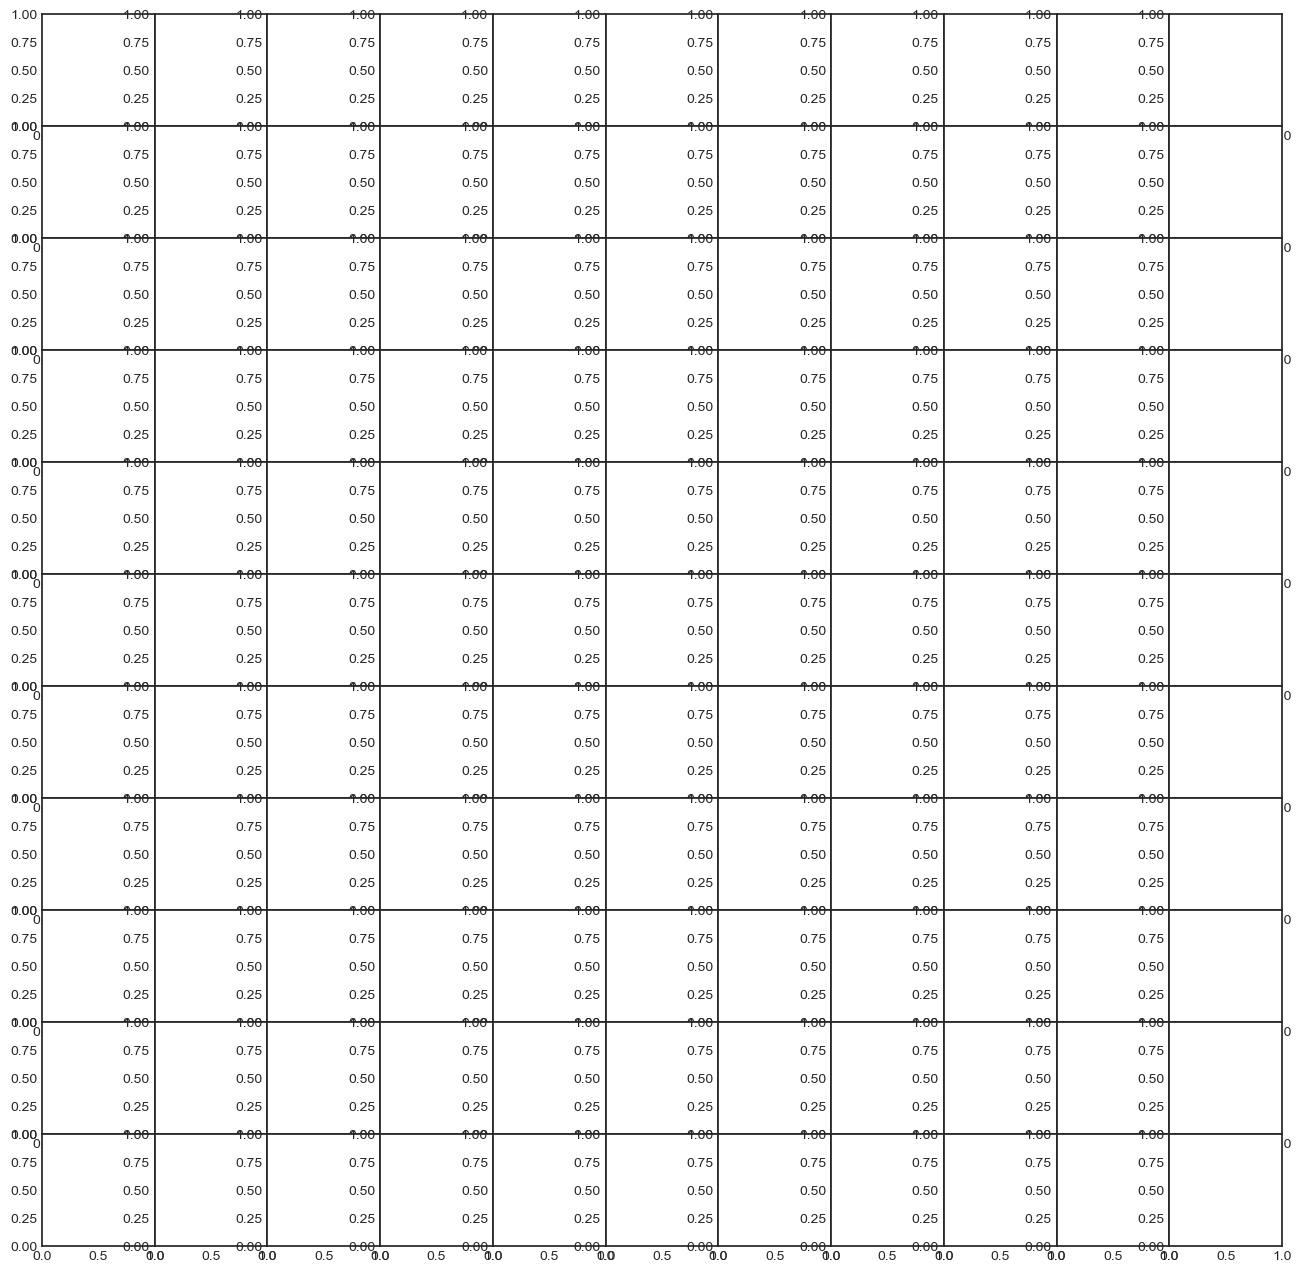

<Figure size 640x480 with 0 Axes>

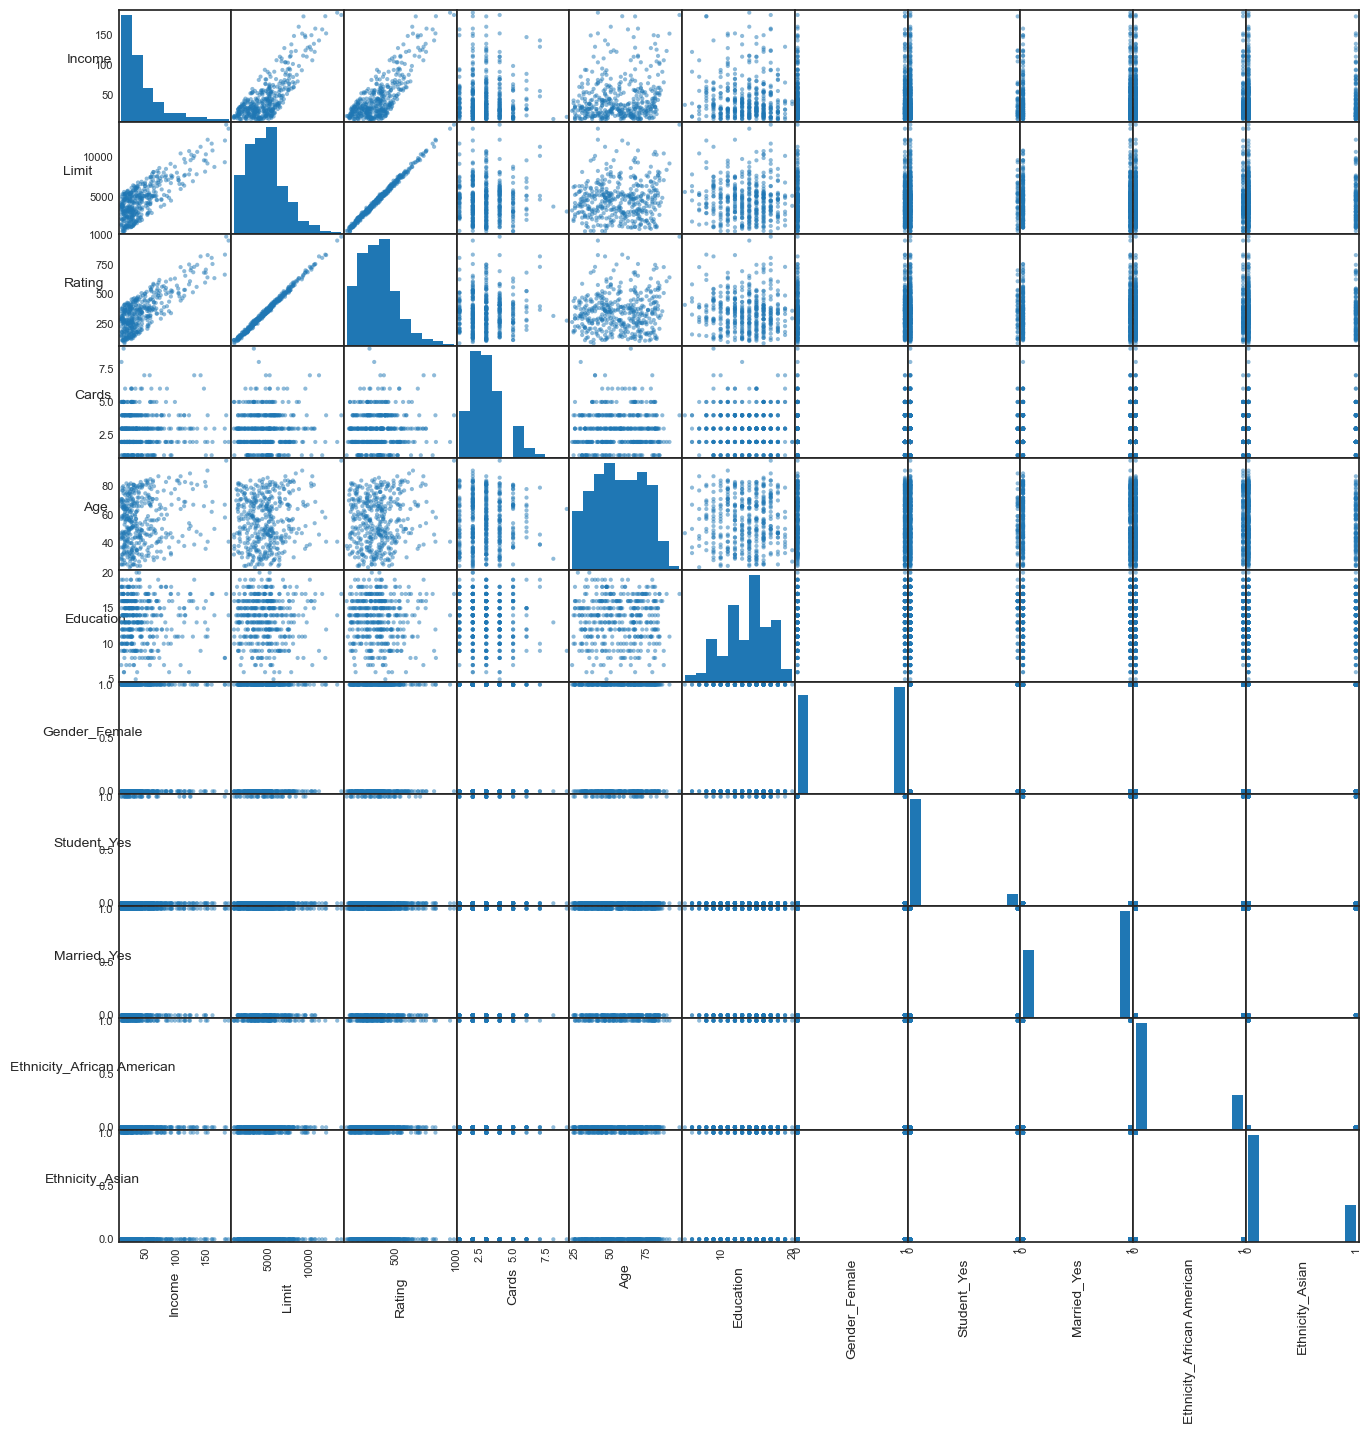

In [8]:
plt.figure()
axes = pd.plotting.scatter_matrix(X.astype(float), figsize=(16,16))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
plt.show()

In [10]:
# 1. Chuyển các cột chữ thành số 0 và 1
X_numeric = pd.get_dummies(X, drop_first=True).astype(float)
# 2. Tính VIF trên X_numeric
vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric.columns
vif_data["VIF"] = [VIF(X_numeric.values, i) for i in range(len(X_numeric.columns))]
print(vif_data)

                       feature          VIF
0                       Income     7.210894
1                        Limit  1076.918485
2                       Rating  1273.228966
3                        Cards     8.178001
4                          Age     9.710669
5                    Education    11.787414
6                Gender_Female     2.042636
7                  Student_Yes     1.146115
8                  Married_Yes     2.646457
9   Ethnicity_African American     1.500733
10             Ethnicity_Asian     1.510362


In [11]:
vif_data.head(11)

,feature,VIF
0,Income,7.210894
1,Limit,1076.918485
2,Rating,1273.228966
3,Cards,8.178001
4,Age,9.710669
5,Education,11.787414
6,Gender_Female,2.042636
7,Student_Yes,1.146115
8,Married_Yes,2.646457
9,Ethnicity_African American,1.500733


<Figure size 640x480 with 0 Axes>

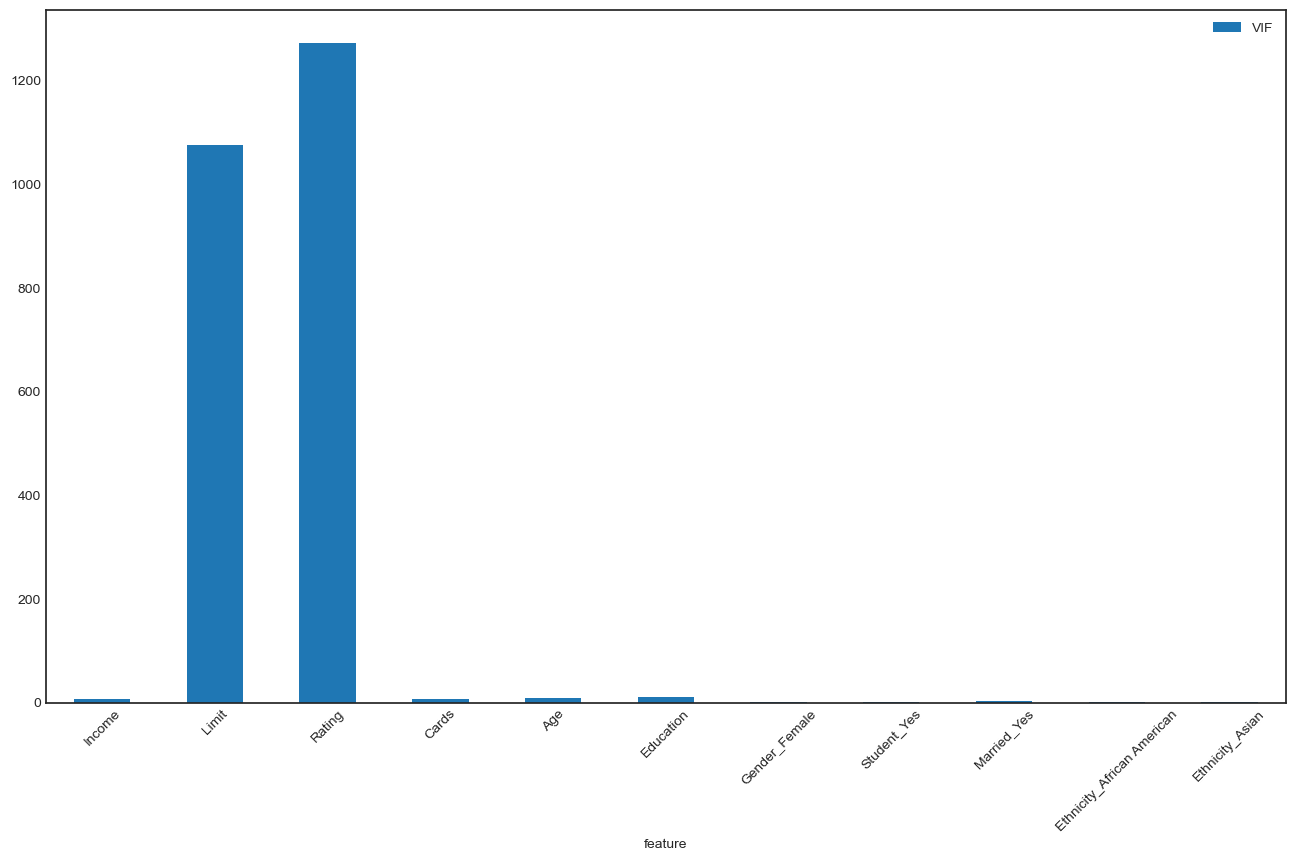

In [12]:
plt.figure()
ax = vif_data.plot.bar(x='feature', y='VIF', rot=45,figsize=(16,9))
plt.show()